# Analisis, limpieza y visualizacion del dataset ARMD

## Objetivo de este notebook

Este notebook documenta la fase previa al modelo de Machine Learning para el proyecto **ARMD-AI**. El trabajo esta centrado en:

- cargar el dataset con cuidado de memoria
- filtrar tempranamente los registros de `STAPHYLOCOCCUS AUREUS`
- unir las tablas minimas necesarias para las variables del proyecto
- analizar el estado original de los datos
- limpiar y normalizar la informacion
- comparar visualmente el estado **antes** y **despues** de la limpieza

La idea es dejar una base clara, explicada y lista para la siguiente fase del proyecto: el modelado predictivo.

## Estructura de carpetas usada en esta fase

- `../data/`: archivos CSV originales del dataset ARMD.
- `../2.VISUALIZACION-DATOS/`: imagenes generadas durante el analisis.
- `../3.DATOS-PROCESADOS/`: archivos limpios y tablas resumen.

Trabajaremos siempre sobre copias en memoria. Los archivos originales en `data/` no se modifican.

In [1]:
# Librerias base para manejo de rutas, memoria, tablas y graficas.
# En este notebook pandas se usa para leer y transformar los CSV.

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 30)
plt.style.use("seaborn-v0_8-whitegrid")

RUTA_PROYECTO = Path.cwd().resolve().parent
RUTA_DATA = RUTA_PROYECTO / "data"
RUTA_GRAFICAS = RUTA_PROYECTO / "2.VISUALIZACION-DATOS"
RUTA_PROCESADOS = RUTA_PROYECTO / "3.DATOS-PROCESADOS"

RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)

for ruta in [RUTA_DATA, RUTA_GRAFICAS, RUTA_PROCESADOS]:
    print(ruta)

D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\data
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\2.VISUALIZACION-DATOS
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS


## Como leer este notebook

Este notebook sigue una secuencia simple: cargar, filtrar, unir, analizar, limpiar, comparar y decidir variables.

Cuando aparezcan metodos importantes como `merge`, `groupby`, `value_counts`, `dropna` o `to_csv`, la idea general queda explicada en el markdown cercano o en comentarios dentro del codigo.


## Estrategia de carga

El dataset es grande y no conviene leer todo sin control. Para evitar gasto innecesario de memoria vamos a seguir estas reglas:

1. Leer solo columnas necesarias con `usecols`.
2. Declarar `dtypes` pequenos cuando sea posible.
3. Convertir los valores `Null`, `null` y vacios a `NaN`.
4. Filtrar a `STAPHYLOCOCCUS AUREUS` tan pronto como se cargue el archivo principal.
5. Liberar memoria con `del` y `gc.collect()` cuando ya no se necesite un DataFrame temporal.

In [2]:
# Aqui definimos constantes y funciones reutilizables para no repetir codigo.
# Este bloque concentra reglas de lectura, limpieza basica y graficas auxiliares.

VALORES_NULOS = ["Null", "null", "NULL", "", " "]
ORGANISMO_OBJETIVO = "STAPHYLOCOCCUS AUREUS"
CLASES_OBJETIVO = ["Susceptible", "Intermediate", "Resistant"]

def cargar_csv(nombre_archivo, usecols=None, dtype=None, parse_dates=None):
    ruta = RUTA_DATA / nombre_archivo
    return pd.read_csv(
        ruta,
        usecols=usecols,
        dtype=dtype,
        parse_dates=parse_dates,
        na_values=VALORES_NULOS,
        keep_default_na=True,
        low_memory=False,
    )

def convertir_a_numerico(df, columnas):
    for col in columnas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def limpiar_texto(df, columnas):
    for col in columnas:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()
    return df

def seleccionar_registro_mas_reciente(df, columna_tiempo, columnas_salida, claves=("order_proc_id_coded",)):
    df = df.copy()
    df[columna_tiempo] = pd.to_numeric(df[columna_tiempo], errors="coerce")
    df = df.dropna(subset=[columna_tiempo])
    df = df.sort_values(list(claves) + [columna_tiempo])
    df = df.groupby(list(claves), as_index=False).first()
    return df[list(claves) + list(columnas_salida)]

def porcentaje_nulos(df):
    resultado = (df.isna().mean() * 100).sort_values(ascending=False)
    return resultado[resultado > 0]

def graficar_barras(serie, titulo, xlabel, ylabel, ruta_guardado, top_n=None, color="#2a6f97"):
    datos = serie.copy()
    if top_n is not None:
        datos = datos.head(top_n)
    fig, ax = plt.subplots(figsize=(12, 6))
    datos.plot(kind="bar", color=color, ax=ax)
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=150, bbox_inches="tight")
    plt.show()

def graficar_nulos(serie_nulos, titulo, ruta_guardado, color="#d62828"):
    if serie_nulos.empty:
        print(f"{titulo}: no hay valores nulos para mostrar.")
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    serie_nulos.sort_values().plot(kind="barh", color=color, ax=ax)
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel("Porcentaje de valores nulos")
    ax.set_ylabel("Variable")
    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=150, bbox_inches="tight")
    plt.show()

def resumen_filas(etapa, df):
    return {
        "etapa": etapa,
        "filas": len(df),
        "columnas": df.shape[1],
        "duplicados_exactos": int(df.duplicated().sum()),
        "ordenes_unicas": int(df["order_proc_id_coded"].nunique()) if "order_proc_id_coded" in df.columns else np.nan,
    }


## 1. Carga del archivo principal y filtro temprano

El archivo principal es `microbiology_cultures_cohort.csv`. Aqui estan el organismo, el antibiotico, el tipo de cultivo y la variable objetivo `susceptibility`.

La limpieza empieza filtrando:

- solo cultivos positivos
- solo registros del organismo objetivo `STAPHYLOCOCCUS AUREUS`

Esto reduce memoria y evita unir millones de filas que no aportan al proyecto.

In [3]:
# Leemos el archivo principal del proyecto y filtramos solo cultivos positivos del organismo objetivo.

columnas_cohort = [
    "anon_id",
    "pat_enc_csn_id_coded",
    "order_proc_id_coded",
    "order_time_jittered_utc",
    "ordering_mode",
    "culture_description",
    "was_positive",
    "organism",
    "antibiotic",
    "susceptibility",
]

dtypes_cohort = {
    "anon_id": "string",
    "pat_enc_csn_id_coded": "string",
    "order_proc_id_coded": "string",
    "ordering_mode": "category",
    "culture_description": "category",
    "was_positive": "Int8",
    "organism": "string",
    "antibiotic": "category",
    "susceptibility": "category",
}

df_cohort = cargar_csv(
    "microbiology_cultures_cohort.csv",
    usecols=columnas_cohort,
    dtype=dtypes_cohort,
    parse_dates=["order_time_jittered_utc"],
)

df_cohort = limpiar_texto(df_cohort, ["anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded", "organism"])
df_cohort["organism"] = df_cohort["organism"].str.upper()

resumen_carga_total = resumen_filas("cohort_completo", df_cohort)
df_cohort_filtrado = df_cohort.loc[
    (df_cohort["was_positive"] == 1) & (df_cohort["organism"] == ORGANISMO_OBJETIVO)
].copy()
resumen_carga_filtrada = resumen_filas("cohort_filtrado_s_aureus", df_cohort_filtrado)

pd.DataFrame([resumen_carga_total, resumen_carga_filtrada])

,etapa,filas,columnas,duplicados_exactos,ordenes_unicas
0,cohort_completo,2241050,10,0,751075
1,cohort_filtrado_s_aureus,82519,10,0,8415


## 2. Analisis inicial del subconjunto bruto

Antes de limpiar en profundidad, conviene observar como llega la informacion del subconjunto de `S. aureus`:

- distribucion de la variable objetivo
- antibioticos mas frecuentes
- tipos de cultivo mas comunes
- porcentaje de nulos en las variables base

Este punto es importante porque nos ayuda a justificar cada paso de limpieza.

## Que mirar en este primer analisis

- si la clase `Susceptible` domina demasiado
- si hay antibioticos muy frecuentes y otros muy raros
- si los tipos de cultivo estan muy concentrados
- si ya aparecen variables con muchos nulos desde el inicio


,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,was_positive,organism,antibiotic,susceptibility
405,JC1245002,131309498310,722915926,2021-05-23 17:17:00+00:00,Outpatient,RESPIRATORY,1,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible
406,JC2474951,131237027276,532673537,2017-08-29 17:54:00+00:00,Outpatient,RESPIRATORY,1,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible
407,JC2790465,131266973373,607899842,2019-04-18 17:28:00+00:00,Inpatient,RESPIRATORY,1,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible
408,JC2526401,131262416443,590232155,2019-01-03 03:46:00+00:00,NaN,RESPIRATORY,1,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible
409,JC696161,131260275836,594498507,2019-02-03 17:50:00+00:00,Outpatient,RESPIRATORY,1,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible


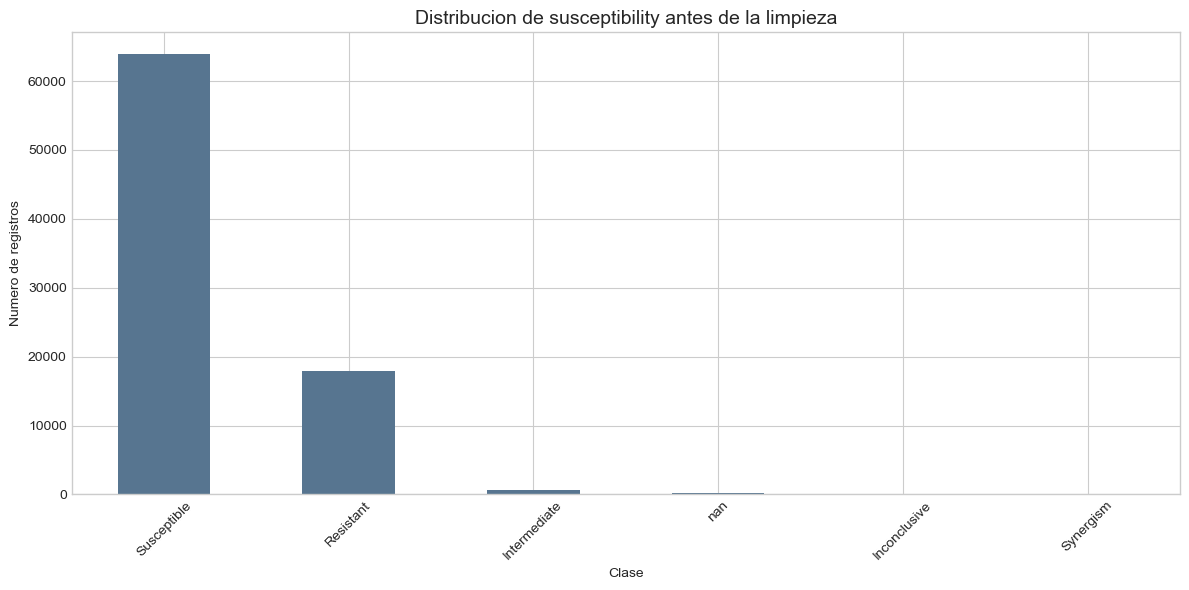

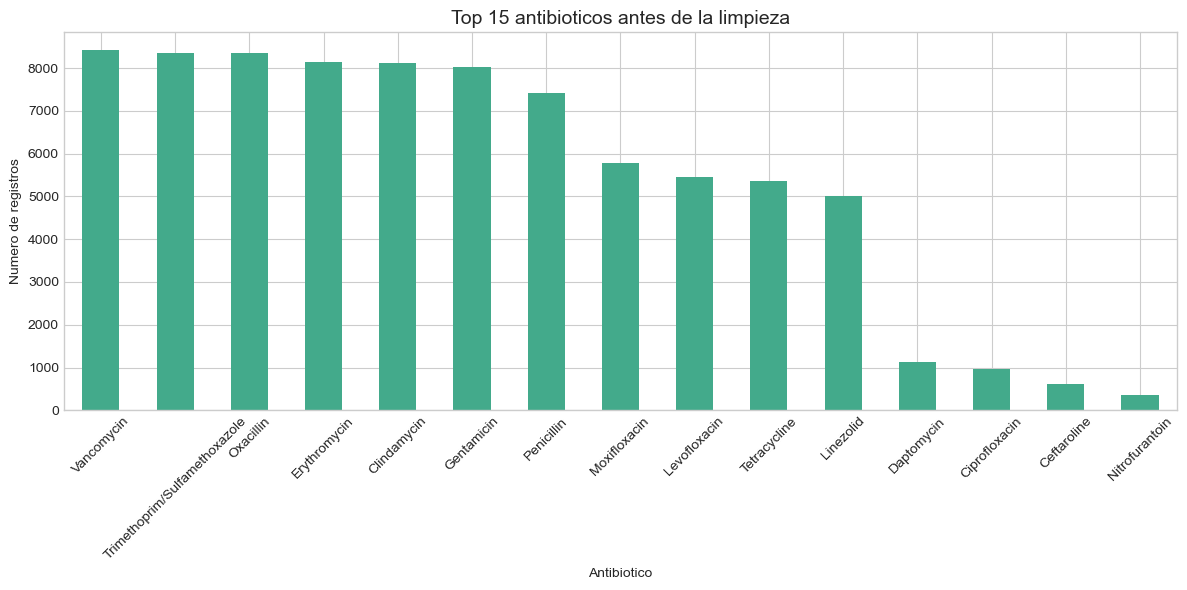

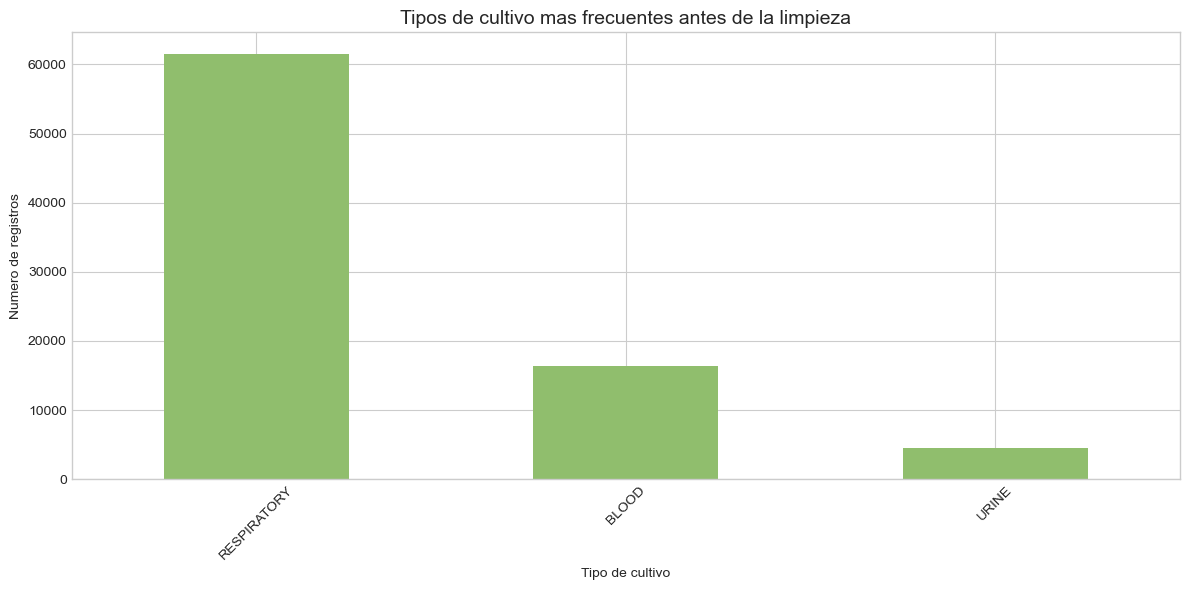

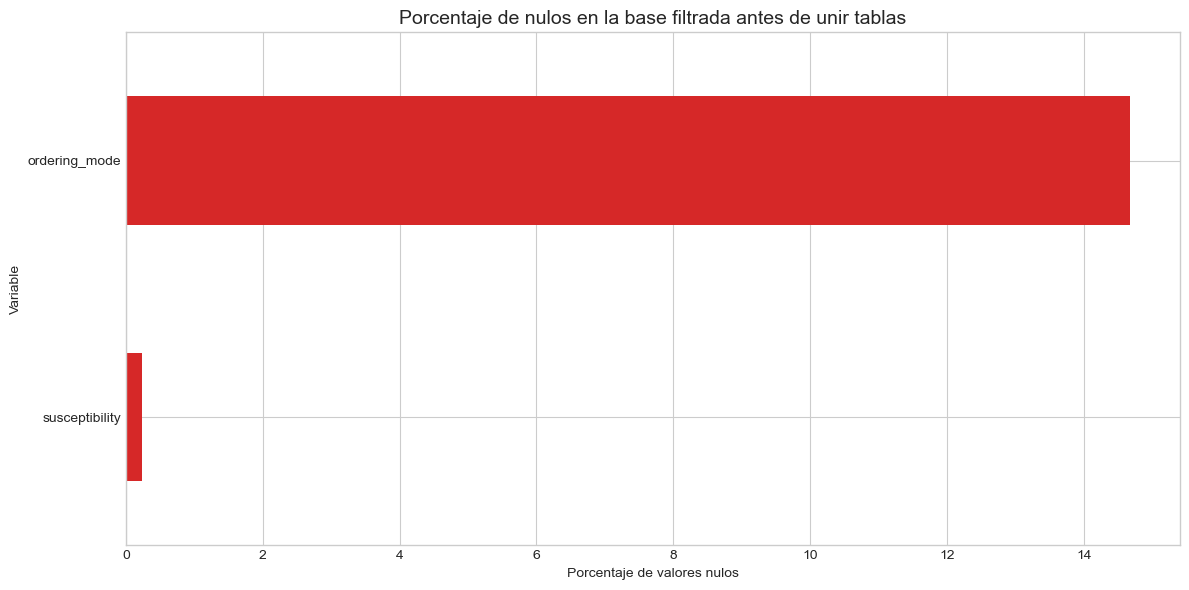

In [4]:
# Cada tabla auxiliar aporta una parte distinta del contexto clinico.
# La idea es leer solo columnas necesarias para ahorrar memoria.

display(df_cohort_filtrado.head())

conteo_susceptibilidad_bruto = df_cohort_filtrado["susceptibility"].value_counts(dropna=False)
conteo_antibioticos_bruto = df_cohort_filtrado["antibiotic"].value_counts(dropna=False)
conteo_cultivos_bruto = df_cohort_filtrado["culture_description"].value_counts(dropna=False)
nulos_brutos = porcentaje_nulos(df_cohort_filtrado)

graficar_barras(
    conteo_susceptibilidad_bruto,
    "Distribucion de susceptibility antes de la limpieza",
    "Clase",
    "Numero de registros",
    RUTA_GRAFICAS / "01_susceptibilidad_antes.png",
    color="#577590",
)

graficar_barras(
    conteo_antibioticos_bruto,
    "Top 15 antibioticos antes de la limpieza",
    "Antibiotico",
    "Numero de registros",
    RUTA_GRAFICAS / "02_top_antibioticos_antes.png",
    top_n=15,
    color="#43aa8b",
)

graficar_barras(
    conteo_cultivos_bruto,
    "Tipos de cultivo mas frecuentes antes de la limpieza",
    "Tipo de cultivo",
    "Numero de registros",
    RUTA_GRAFICAS / "03_cultivos_antes.png",
    top_n=15,
    color="#90be6d",
)

graficar_nulos(
    nulos_brutos,
    "Porcentaje de nulos en la base filtrada antes de unir tablas",
    RUTA_GRAFICAS / "04_nulos_base_antes.png",
)

## 3. Carga de tablas complementarias y uniones necesarias

Para esta fase no vamos a usar todo el dataset. Solo cargamos las tablas que alimentan las variables definidas en `PROJECT_CONTEXT.md`:

- `demographics`
- `ward_info`
- `labs`
- `antibiotic_class_exposure`
- `prior_infecting_organism`
- `nursing_home_visits`
- `priorprocedures`
- `implied_susceptibility`
- `implied_susceptibility_rules`

Las tablas con multiples filas por orden se agregan para quedarnos con el registro mas cercano o mas util para esta fase exploratoria.

In [5]:
# merge une tablas por una llave comun.
# how="left" significa: conservar todas las filas de la tabla principal aunque falten datos en la tabla auxiliar.

claves_principales = ["order_proc_id_coded"]

df_demo = cargar_csv(
    "microbiology_cultures_demographics.csv",
    usecols=["order_proc_id_coded", "age", "gender"],
    dtype={"order_proc_id_coded": "string", "age": "category", "gender": "string"},
).drop_duplicates(subset=claves_principales)

df_ward = cargar_csv(
    "microbiology_cultures_ward_info.csv",
    usecols=["order_proc_id_coded", "hosp_ward_ER", "hosp_ward_ICU", "hosp_ward_IP", "hosp_ward_OP"],
    dtype={
        "order_proc_id_coded": "string",
        "hosp_ward_ER": "float32",
        "hosp_ward_ICU": "float32",
        "hosp_ward_IP": "float32",
        "hosp_ward_OP": "float32",
    },
).drop_duplicates(subset=claves_principales)

df_labs = cargar_csv(
    "microbiology_cultures_labs.csv",
    usecols=["order_proc_id_coded", "Period_Day", "median_wbc", "median_cr"],
    dtype={"order_proc_id_coded": "string", "Period_Day": "float32", "median_wbc": "float32", "median_cr": "float32"},
)
df_labs = convertir_a_numerico(df_labs, ["Period_Day", "median_wbc", "median_cr"])
if (df_labs["Period_Day"] == 14).any():
    df_labs = df_labs.loc[df_labs["Period_Day"] == 14].copy()
else:
    df_labs = df_labs.sort_values(["order_proc_id_coded", "Period_Day"]).groupby("order_proc_id_coded", as_index=False).last()
df_labs = df_labs[["order_proc_id_coded", "median_wbc", "median_cr"]].drop_duplicates(subset=claves_principales)

df_abx = cargar_csv(
    "microbiology_cultures_antibiotic_class_exposure.csv",
    usecols=["order_proc_id_coded", "antibiotic_class", "time_to_culturetime"],
    dtype={"order_proc_id_coded": "string", "antibiotic_class": "string", "time_to_culturetime": "float32"},
)
df_abx = seleccionar_registro_mas_reciente(
    df_abx,
    "time_to_culturetime",
    columnas_salida=["antibiotic_class", "time_to_culturetime"],
)

df_prior = cargar_csv(
    "microbiology_culture_prior_infecting_organism.csv",
    usecols=["order_proc_id_coded", "prior_organism", "prior_infecting_organism_days_to_culutre"],
    dtype={"order_proc_id_coded": "string", "prior_organism": "string", "prior_infecting_organism_days_to_culutre": "float32"},
)
df_prior = limpiar_texto(df_prior, ["prior_organism"])
df_prior["prior_organism"] = df_prior["prior_organism"].str.upper()
df_prior = df_prior.loc[df_prior["prior_organism"] == ORGANISMO_OBJETIVO].copy()
df_prior = seleccionar_registro_mas_reciente(
    df_prior,
    "prior_infecting_organism_days_to_culutre",
    columnas_salida=["prior_organism", "prior_infecting_organism_days_to_culutre"],
)
df_prior = df_prior.rename(columns={"prior_infecting_organism_days_to_culutre": "prior_infecting_organism_days_to_culture"})

df_nursing = cargar_csv(
    "microbiology_cultures_nursing_home_visits.csv",
    usecols=["order_proc_id_coded", "nursing_home_visit_culture"],
    dtype={"order_proc_id_coded": "string", "nursing_home_visit_culture": "float32"},
).drop_duplicates(subset=claves_principales)

df_proc = cargar_csv(
    "microbiology_cultures_priorprocedures.csv",
    usecols=["order_proc_id_coded", "procedure_description", "procedure_time_to_culturetime"],
    dtype={"order_proc_id_coded": "string", "procedure_description": "string", "procedure_time_to_culturetime": "float32"},
)
df_proc = seleccionar_registro_mas_reciente(
    df_proc,
    "procedure_time_to_culturetime",
    columnas_salida=["procedure_description"],
)
df_proc = df_proc.rename(columns={"procedure_description": "procedure_name"})

df_implied = cargar_csv(
    "microbiology_cultures_implied_susceptibility.csv",
    usecols=["order_proc_id_coded", "organism", "antibiotic", "implied_susceptibility"],
    dtype={"order_proc_id_coded": "string", "organism": "string", "antibiotic": "string", "implied_susceptibility": "string"},
)
df_implied = limpiar_texto(df_implied, ["organism", "antibiotic", "implied_susceptibility"])
df_implied["organism"] = df_implied["organism"].str.upper()
df_implied = df_implied.loc[df_implied["organism"] == ORGANISMO_OBJETIVO].copy()
df_implied = df_implied.drop_duplicates(subset=["order_proc_id_coded", "antibiotic"])

df_rules = cargar_csv(
    "implied_susceptibility_rules.csv",
    usecols=["Organism", "Antibiotic", "Rule"],
    dtype={"Organism": "string", "Antibiotic": "string", "Rule": "string"},
)
df_rules = limpiar_texto(df_rules, ["Organism", "Antibiotic", "Rule"])
df_rules["Organism"] = df_rules["Organism"].str.upper()
df_rules = df_rules.loc[df_rules["Organism"] == ORGANISMO_OBJETIVO].copy()

for nombre, df_temp in {
    "demographics": df_demo,
    "ward": df_ward,
    "labs": df_labs,
    "antibiotic_class": df_abx,
    "prior_organism": df_prior,
    "nursing": df_nursing,
    "procedures": df_proc,
    "implied": df_implied,
    "rules": df_rules,
}.items():
    print(nombre, df_temp.shape)


demographics (751075, 3)
ward (751075, 5)
labs (492659, 3)
antibiotic_class (484370, 3)
prior_organism (0, 3)
nursing (7369, 2)
procedures (251759, 2)
implied (76864, 4)
rules (0, 3)


## 4. Construccion de una base analitica unificada

En esta etapa unimos todo sobre `order_proc_id_coded`. No estamos entrenando el modelo todavia. Solo estamos formando una tabla analitica coherente para estudiar calidad, distribuciones y limpieza.

In [6]:
# La limpieza empieza copiando la base analitica para no modificar la version previa.
# dropna elimina filas con faltantes en columnas criticas y drop_duplicates evita duplicados exactos.

df_analisis = df_cohort_filtrado.copy()
df_analisis = df_analisis.merge(df_demo, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(df_ward, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(df_labs, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(df_abx, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(df_prior, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(df_nursing, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(df_proc, on="order_proc_id_coded", how="left")
df_analisis = df_analisis.merge(
    df_implied[["order_proc_id_coded", "antibiotic", "implied_susceptibility"]],
    on=["order_proc_id_coded", "antibiotic"],
    how="left",
)
df_analisis = df_analisis.merge(
    df_rules[["Antibiotic", "Rule"]],
    left_on="antibiotic",
    right_on="Antibiotic",
    how="left",
)
df_analisis = df_analisis.drop(columns=["Antibiotic"], errors="ignore")

columnas_finales = [
    "anon_id",
    "pat_enc_csn_id_coded",
    "order_proc_id_coded",
    "order_time_jittered_utc",
    "ordering_mode",
    "culture_description",
    "organism",
    "antibiotic",
    "susceptibility",
    "age",
    "gender",
    "hosp_ward_ICU",
    "hosp_ward_ER",
    "hosp_ward_IP",
    "hosp_ward_OP",
    "antibiotic_class",
    "time_to_culturetime",
    "prior_organism",
    "prior_infecting_organism_days_to_culture",
    "nursing_home_visit_culture",
    "procedure_name",
    "implied_susceptibility",
    "Rule",
    "median_wbc",
    "median_cr",
]
df_analisis = df_analisis[columnas_finales].copy()

display(df_analisis.head())
display(pd.DataFrame([resumen_filas("base_analitica_antes_limpieza", df_analisis)]))
display(porcentaje_nulos(df_analisis).to_frame("porcentaje_nulos").head(20))

del df_demo, df_ward, df_labs, df_abx, df_prior, df_nursing, df_proc, df_implied, df_rules
gc.collect()

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,organism,antibiotic,susceptibility,age,gender,hosp_ward_ICU,hosp_ward_ER,hosp_ward_IP,hosp_ward_OP,antibiotic_class,time_to_culturetime,prior_organism,prior_infecting_organism_days_to_culture,nursing_home_visit_culture,procedure_name,implied_susceptibility,Rule,median_wbc,median_cr
0,JC1245002,131309498310,722915926,2021-05-23 17:17:00+00:00,Outpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,55-64 years,1,0.0,0.0,0.0,1.0,Fluoroquinolone,22.0,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
1,JC2474951,131237027276,532673537,2017-08-29 17:54:00+00:00,Outpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,18-24 years,0,0.0,0.0,0.0,1.0,Macrolide Lincosamide,428.0,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
2,JC2790465,131266973373,607899842,2019-04-18 17:28:00+00:00,Inpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,65-74 years,1,1.0,0.0,1.0,0.0,Beta Lactam,1.0,<NA>,NaN,NaN,mechvent,<NA>,<NA>,19.700001,0.97
3,JC2526401,131262416443,590232155,2019-01-03 03:46:00+00:00,NaN,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,25-34 years,0,0.0,0.0,0.0,0.0,<NA>,NaN,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
4,JC696161,131260275836,594498507,2019-02-03 17:50:00+00:00,Outpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,45-54 years,0,0.0,0.0,0.0,1.0,Beta Lactam,42.0,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN


,etapa,filas,columnas,duplicados_exactos,ordenes_unicas
0,base_analitica_antes_limpieza,82519,25,0,8415


,porcentaje_nulos
implied_susceptibility,100.000000
prior_organism,100.000000
prior_infecting_organism_days_to_culture,100.000000
Rule,100.000000
nursing_home_visit_culture,99.254717
median_wbc,68.272761
median_cr,68.217017
procedure_name,65.515821
time_to_culturetime,29.781020
antibiotic_class,29.781020


11300

## 5. Limpieza y normalizacion

Aqui aplicamos reglas concretas y justificadas:

1. Eliminar registros sin antibiotico, sin cultivo o sin clase objetivo valida.
2. Conservar solo `Susceptible`, `Intermediate` y `Resistant`.
3. Estandarizar texto en variables categoricas.
4. Convertir banderas del hospital a `0/1`.
5. Mantener los nulos clinicos reales en variables numericas como `median_wbc` y `median_cr`.
6. Usar etiquetas semanticas como `SIN_REGISTRO` o `SIN_REGLA` en categoricas donde no conviene perder la fila.

Observacion importante: no hacemos imputacion estadistica ciega. Eso respeta la restriccion del proyecto.

In [7]:
# Aqui comparamos visualmente antes vs despues.
# La idea es verificar si la limpieza mejoro la interpretabilidad sin destruir demasiados datos.

df_limpio = df_analisis.copy()

columnas_texto = [
    "ordering_mode",
    "culture_description",
    "antibiotic",
    "susceptibility",
    "age",
    "gender",
    "antibiotic_class",
    "prior_organism",
    "procedure_name",
    "implied_susceptibility",
    "Rule",
]
df_limpio = limpiar_texto(df_limpio, columnas_texto)

df_limpio = df_limpio.dropna(subset=["antibiotic", "culture_description", "susceptibility"])
df_limpio = df_limpio.loc[df_limpio["susceptibility"].isin(CLASES_OBJETIVO)].copy()
df_limpio = df_limpio.drop_duplicates()

for col in ["hosp_ward_ICU", "hosp_ward_ER", "hosp_ward_IP", "hosp_ward_OP"]:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce").fillna(0).astype("int8")

for col in ["time_to_culturetime", "prior_infecting_organism_days_to_culture", "nursing_home_visit_culture", "median_wbc", "median_cr"]:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

df_limpio["age"] = df_limpio["age"].fillna("SIN_REGISTRO")
df_limpio["gender"] = df_limpio["gender"].fillna("SIN_REGISTRO")
df_limpio["antibiotic_class"] = df_limpio["antibiotic_class"].fillna("SIN_REGISTRO")
df_limpio["prior_organism"] = df_limpio["prior_organism"].fillna("SIN_REGISTRO")
df_limpio["procedure_name"] = df_limpio["procedure_name"].fillna("SIN_REGISTRO")
df_limpio["implied_susceptibility"] = df_limpio["implied_susceptibility"].fillna("SIN_REGLA")
df_limpio["Rule"] = df_limpio["Rule"].fillna("SIN_REGLA")

resumen_antes = resumen_filas("antes_limpieza", df_analisis)
resumen_despues = resumen_filas("despues_limpieza", df_limpio)
df_resumen_filas = pd.DataFrame([resumen_antes, resumen_despues])
display(df_resumen_filas)
display(df_limpio.head())


,etapa,filas,columnas,duplicados_exactos,ordenes_unicas
0,antes_limpieza,82519,25,0,8415
1,despues_limpieza,82319,25,0,8414


,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,organism,antibiotic,susceptibility,age,gender,hosp_ward_ICU,hosp_ward_ER,hosp_ward_IP,hosp_ward_OP,antibiotic_class,time_to_culturetime,prior_organism,prior_infecting_organism_days_to_culture,nursing_home_visit_culture,procedure_name,implied_susceptibility,Rule,median_wbc,median_cr
0,JC1245002,131309498310,722915926,2021-05-23 17:17:00+00:00,Outpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,55-64 years,1,0,0,0,1,Fluoroquinolone,22.0,SIN_REGISTRO,NaN,NaN,SIN_REGISTRO,SIN_REGLA,SIN_REGLA,NaN,NaN
1,JC2474951,131237027276,532673537,2017-08-29 17:54:00+00:00,Outpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,18-24 years,0,0,0,0,1,Macrolide Lincosamide,428.0,SIN_REGISTRO,NaN,NaN,SIN_REGISTRO,SIN_REGLA,SIN_REGLA,NaN,NaN
2,JC2790465,131266973373,607899842,2019-04-18 17:28:00+00:00,Inpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,65-74 years,1,1,0,1,0,Beta Lactam,1.0,SIN_REGISTRO,NaN,NaN,mechvent,SIN_REGLA,SIN_REGLA,19.700001,0.97
3,JC2526401,131262416443,590232155,2019-01-03 03:46:00+00:00,<NA>,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,25-34 years,0,0,0,0,0,SIN_REGISTRO,NaN,SIN_REGISTRO,NaN,NaN,SIN_REGISTRO,SIN_REGLA,SIN_REGLA,NaN,NaN
4,JC696161,131260275836,594498507,2019-02-03 17:50:00+00:00,Outpatient,RESPIRATORY,STAPHYLOCOCCUS AUREUS,Linezolid,Susceptible,45-54 years,0,0,0,0,1,Beta Lactam,42.0,SIN_REGISTRO,NaN,NaN,SIN_REGISTRO,SIN_REGLA,SIN_REGLA,NaN,NaN


## 6. Comparacion visual: antes vs despues

En esta seccion medimos si la limpieza realmente mejoro la base. Las comparaciones principales son:

- tamano del dataset
- distribucion de la variable objetivo
- porcentaje de nulos en variables clave
- distribucion de los tipos de cultivo y de los antibioticos mas frecuentes

Estas graficas son utiles para explicar el proceso en clase o en el informe.

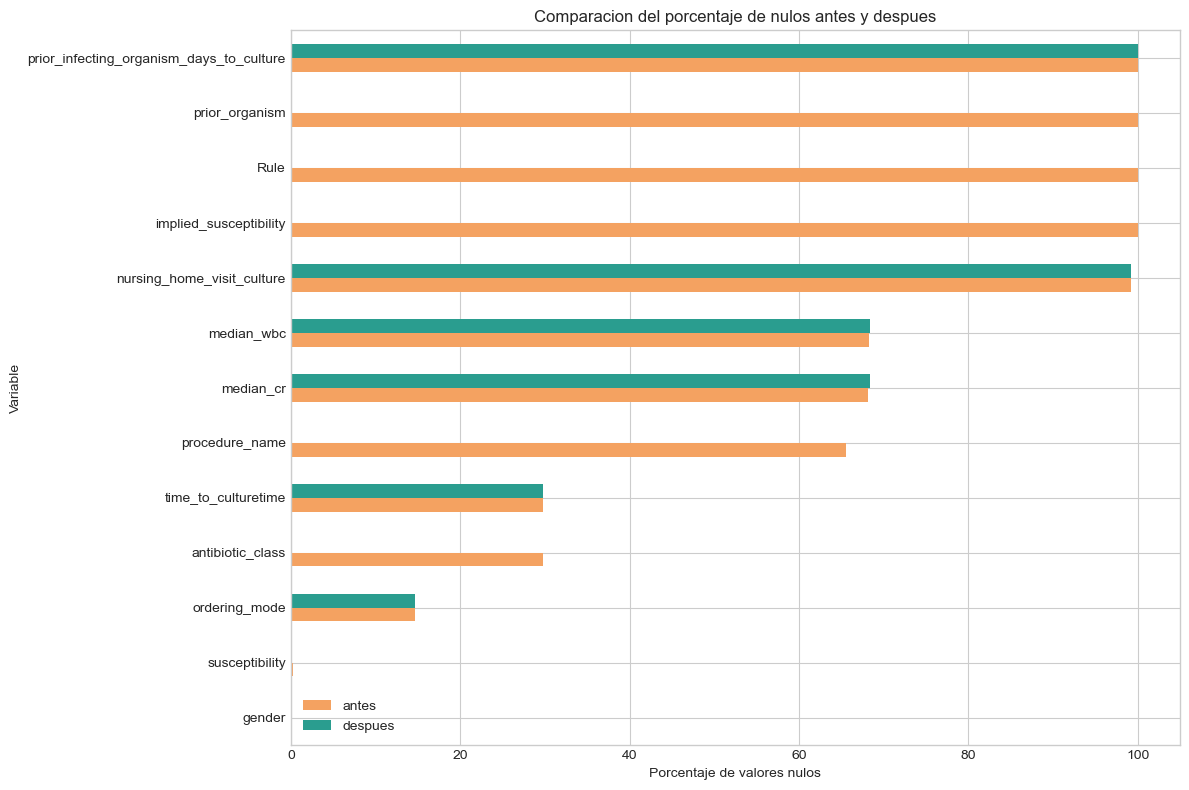

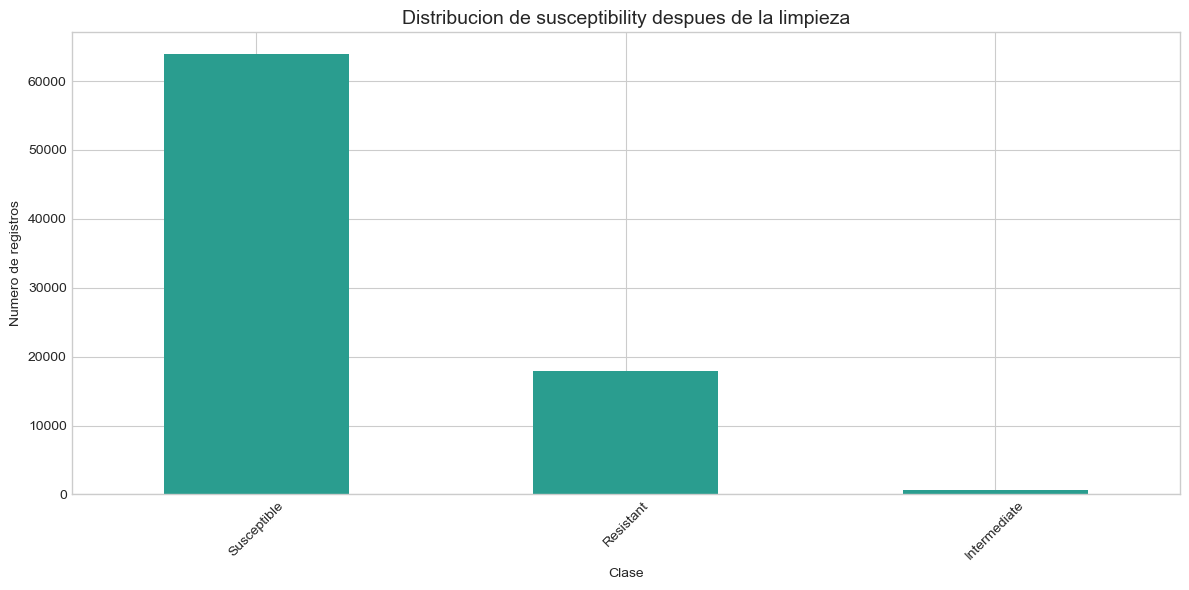

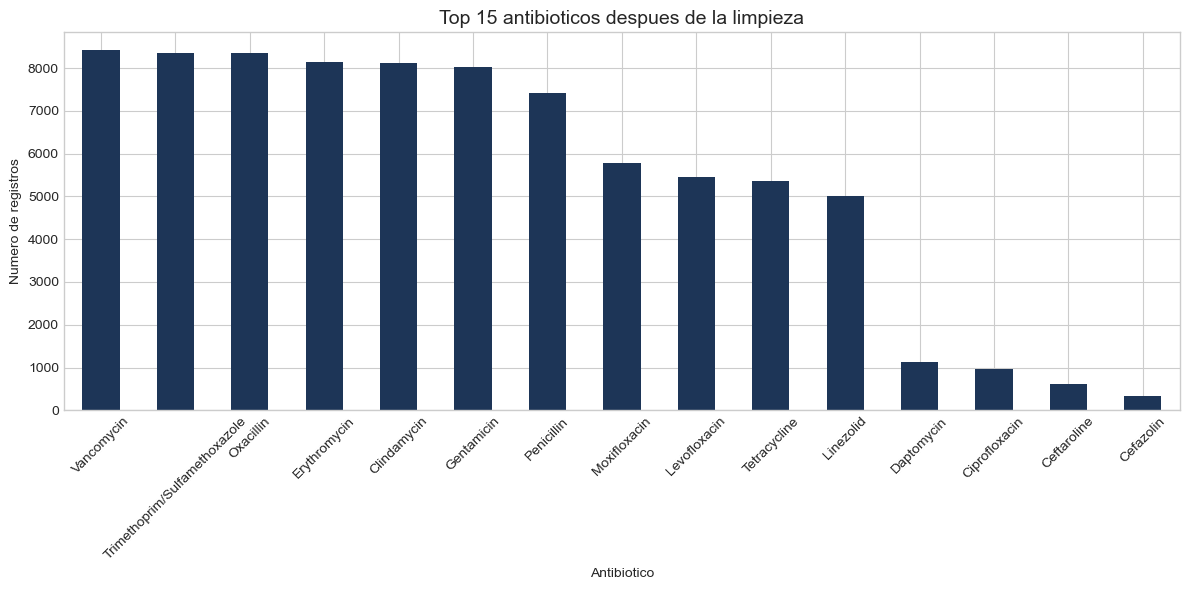

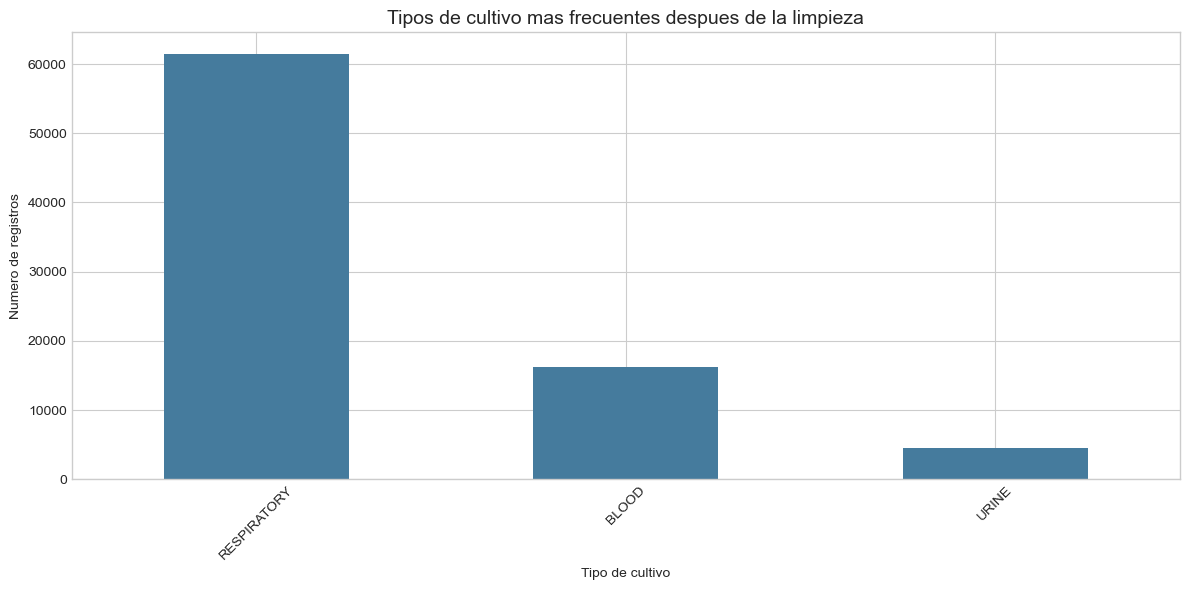

In [8]:
# concat permite unir tablas por columnas; aqui se usa para comparar la distribucion de susceptibility antes y despues.

nulos_antes = porcentaje_nulos(df_analisis)
nulos_despues = porcentaje_nulos(df_limpio)

claves_nulos = sorted(set(nulos_antes.index).union(set(nulos_despues.index)))
comparacion_nulos = pd.DataFrame({
    "antes": nulos_antes.reindex(claves_nulos, fill_value=0),
    "despues": nulos_despues.reindex(claves_nulos, fill_value=0),
}).sort_values("antes", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
comparacion_nulos.tail(15).plot(kind="barh", ax=ax, color=["#f4a261", "#2a9d8f"])
ax.set_title("Comparacion del porcentaje de nulos antes y despues")
ax.set_xlabel("Porcentaje de valores nulos")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.savefig(RUTA_GRAFICAS / "05_nulos_antes_vs_despues.png", dpi=150, bbox_inches="tight")
plt.show()

graficar_barras(
    df_limpio["susceptibility"].value_counts(),
    "Distribucion de susceptibility despues de la limpieza",
    "Clase",
    "Numero de registros",
    RUTA_GRAFICAS / "06_susceptibilidad_despues.png",
    color="#2a9d8f",
)

graficar_barras(
    df_limpio["antibiotic"].value_counts(),
    "Top 15 antibioticos despues de la limpieza",
    "Antibiotico",
    "Numero de registros",
    RUTA_GRAFICAS / "07_top_antibioticos_despues.png",
    top_n=15,
    color="#1d3557",
)

graficar_barras(
    df_limpio["culture_description"].value_counts(),
    "Tipos de cultivo mas frecuentes despues de la limpieza",
    "Tipo de cultivo",
    "Numero de registros",
    RUTA_GRAFICAS / "08_cultivos_despues.png",
    top_n=15,
    color="#457b9d",
)

## Como interpretar la verificacion final de variables

- `usar`: variable estable y util para la siguiente fase
- `usar con cuidado`: puede servir, pero necesita tratamiento especial o tiene muchos faltantes
- `excluir`: no aporta suficiente informacion en esta version de la base


## 7. Tablas resumen para interpretar el resultado

No basta con ver graficas. Tambien es util dejar tablas comparativas listas para el informe final o para copiar a un documento.

In [9]:
# Estas tablas resumen ayudan a interpretar el dataset sin mirar millones de filas una por una.

tabla_susceptibilidad = pd.concat(
    [
        df_cohort_filtrado["susceptibility"].value_counts(dropna=False).rename("antes"),
        df_limpio["susceptibility"].value_counts(dropna=False).rename("despues"),
    ],
    axis=1,
).fillna(0)

tabla_cultivos = df_limpio["culture_description"].value_counts().to_frame("frecuencia")
tabla_antibioticos = df_limpio["antibiotic"].value_counts().head(20).to_frame("frecuencia")
tabla_nulos = comparacion_nulos.sort_values("antes", ascending=False)

display(tabla_susceptibilidad)
display(tabla_cultivos.head(15))
display(tabla_antibioticos)
display(tabla_nulos.head(20))


,antes,despues
susceptibility,,
Susceptible,63876,63876
Resistant,17866,17866
Intermediate,577,577
<NA>,196,0
Inconclusive,4,0
Synergism,0,0


,frecuencia
culture_description,
RESPIRATORY,61502
BLOOD,16262
URINE,4555


,frecuencia
antibiotic,
Vancomycin,8414
Trimethoprim/Sulfamethoxazole,8352
Oxacillin,8342
Erythromycin,8132
Clindamycin,8126
Gentamicin,8021
Penicillin,7422
Moxifloxacin,5787
Levofloxacin,5449


,antes,despues
prior_infecting_organism_days_to_culture,100.000000,100.000000
implied_susceptibility,100.000000,0.000000
Rule,100.000000,0.000000
prior_organism,100.000000,0.000000
nursing_home_visit_culture,99.254717,99.257766
median_wbc,68.272761,68.416769
median_cr,68.217017,68.362104
procedure_name,65.515821,0.000000
time_to_culturetime,29.781020,29.769555
antibiotic_class,29.781020,0.000000


## 8. Verificacion final de variables para modelado

Esta es la ultima revision antes de pasar a la fase de entrenamiento. Aqui no buscamos entrenar todavia, sino decidir con criterio tecnico que variables vale la pena conservar.

La logica sera esta:

- `usar`: la variable tiene cobertura razonable y sentido clinico claro.
- `usar con cuidado`: la variable tiene valor potencial, pero exige precaucion por nulos, rareza o interpretacion.
- `excluir`: la variable no tiene suficiente informacion util en esta version de la base o puede introducir mucho ruido.

Importante: esta tabla no es un capricho. Sirve para justificar de manera academica por que unas variables pasan al modelo y otras no.

In [10]:
# nunique cuenta valores distintos y ayuda a detectar variables constantes o casi sin variacion.

porcentaje_nulos_final = (df_limpio.isna().mean() * 100).round(2)
cardinalidad_final = df_limpio.nunique(dropna=True)

# Esta tabla formaliza la decision tecnica de cada variable antes del modelado.
reglas_variables = {
    "order_time_jittered_utc": {
        "tipo": "temporal",
        "decision": "usar con cuidado",
        "justificacion": "Sirve para hacer la particion temporal y evitar data leakage. No debe entrar como predictor crudo al modelo final.",
    },
    "ordering_mode": {
        "tipo": "categorica",
        "decision": "usar con cuidado",
        "justificacion": "Tiene valor operativo, pero presenta alrededor de 15% de nulos y puede requerir imputacion controlada.",
    },
    "culture_description": {
        "tipo": "categorica",
        "decision": "usar",
        "justificacion": "Tiene fuerte sentido clinico y buena cobertura. El sitio anatomico puede influir en el patron de resistencia.",
    },
    "antibiotic": {
        "tipo": "categorica",
        "decision": "usar",
        "justificacion": "Es una variable central del problema, porque la resistencia depende del antibiotico evaluado.",
    },
    "age": {
        "tipo": "categorica",
        "decision": "usar",
        "justificacion": "Tiene sentido clinico y buena cobertura. La edad puede relacionarse con comorbilidad y exposicion hospitalaria.",
    },
    "gender": {
        "tipo": "categorica",
        "decision": "usar",
        "justificacion": "Tiene cobertura casi completa y puede mantenerse como variable demografica basica.",
    },
    "hosp_ward_ICU": {
        "tipo": "binaria",
        "decision": "usar",
        "justificacion": "La UCI es clinicamente relevante por mayor presion antibiotica y gravedad del paciente.",
    },
    "hosp_ward_ER": {
        "tipo": "binaria",
        "decision": "usar",
        "justificacion": "Ayuda a distinguir contextos de atencion con diferentes perfiles epidemiologicos.",
    },
    "hosp_ward_IP": {
        "tipo": "binaria",
        "decision": "usar",
        "justificacion": "Es util para separar hospitalizacion de otros contextos de toma de muestra.",
    },
    "hosp_ward_OP": {
        "tipo": "binaria",
        "decision": "usar",
        "justificacion": "Complementa la informacion del entorno clinico y ayuda a diferenciar pacientes ambulatorios.",
    },
    "antibiotic_class": {
        "tipo": "categorica",
        "decision": "usar con cuidado",
        "justificacion": "Tiene sentido clinico, pero una parte importante de los registros no trae antecedente de exposicion antibiotica.",
    },
    "time_to_culturetime": {
        "tipo": "numerica",
        "decision": "usar con cuidado",
        "justificacion": "Puede aportar informacion temporal sobre exposicion previa, pero tiene nulos y requiere tratamiento dentro del pipeline.",
    },
    "prior_organism": {
        "tipo": "categorica",
        "decision": "excluir",
        "justificacion": "En esta version de la base quedo sin informacion util por una regla de filtrado demasiado estricta. Debe corregirse antes de usarse.",
    },
    "prior_infecting_organism_days_to_culture": {
        "tipo": "numerica",
        "decision": "excluir",
        "justificacion": "Quedo completamente vacia en esta version de la base, por lo que no aporta senal real al modelo.",
    },
    "nursing_home_visit_culture": {
        "tipo": "numerica",
        "decision": "excluir",
        "justificacion": "Tiene cerca de 99% de nulos. Mantenerla en esta etapa probablemente agrega mas ruido que informacion.",
    },
    "procedure_name": {
        "tipo": "categorica",
        "decision": "usar con cuidado",
        "justificacion": "Tiene sentido clinico, pero originalmente venia con mucho faltante y fue necesario rellenarla como categoria explicita.",
    },
    "implied_susceptibility": {
        "tipo": "categorica",
        "decision": "excluir",
        "justificacion": "Para esta bacteria la fuente consultada llega practicamente vacia, asi que no aporta informacion diferencial en esta version.",
    },
    "Rule": {
        "tipo": "categorica",
        "decision": "excluir",
        "justificacion": "Quedo sin informacion util despues del cruce actual y no justifica entrar al modelo en esta iteracion.",
    },
    "median_wbc": {
        "tipo": "numerica",
        "decision": "usar con cuidado",
        "justificacion": "Tiene valor clinico claro, pero la cobertura es baja y exigira imputacion dentro del pipeline de modelado.",
    },
    "median_cr": {
        "tipo": "numerica",
        "decision": "usar con cuidado",
        "justificacion": "Es una variable clinica relevante, aunque tambien presenta muchos faltantes y no debe interpretarse sin cautela.",
    },
}

filas_verificacion = []
for variable, meta in reglas_variables.items():
    filas_verificacion.append({
        "variable": variable,
        "tipo": meta["tipo"],
        "porcentaje_nulos": float(porcentaje_nulos_final.get(variable, 0.0)),
        "cardinalidad": int(cardinalidad_final.get(variable, 0)),
        "decision": meta["decision"],
        "justificacion": meta["justificacion"],
    })

df_verificacion_variables = pd.DataFrame(filas_verificacion)
df_verificacion_variables = df_verificacion_variables.sort_values(
    by=["decision", "porcentaje_nulos"],
    ascending=[True, False],
).reset_index(drop=True)

display(df_verificacion_variables)
display(df_verificacion_variables["decision"].value_counts().to_frame("cantidad_variables"))


,variable,tipo,porcentaje_nulos,cardinalidad,decision,justificacion
0,prior_infecting_organism_days_to_culture,numerica,100.00,0,excluir,Quedo completamente vacia en esta version de l...
1,nursing_home_visit_culture,numerica,99.26,9,excluir,Tiene cerca de 99% de nulos. Mantenerla en est...
2,prior_organism,categorica,0.00,1,excluir,En esta version de la base quedo sin informaci...
3,implied_susceptibility,categorica,0.00,1,excluir,Para esta bacteria la fuente consultada llega ...
4,Rule,categorica,0.00,1,excluir,Quedo sin informacion util despues del cruce a...
5,culture_description,categorica,0.00,3,usar,Tiene fuerte sentido clinico y buena cobertura...
6,antibiotic,categorica,0.00,23,usar,"Es una variable central del problema, porque l..."
7,age,categorica,0.00,9,usar,Tiene sentido clinico y buena cobertura. La ed...
8,gender,categorica,0.00,3,usar,Tiene cobertura casi completa y puede mantener...
9,hosp_ward_ICU,binaria,0.00,2,usar,La UCI es clinicamente relevante por mayor pre...


,cantidad_variables
decision,
usar,8
usar con cuidado,7
excluir,5


## 9. Guardado de resultados

En esta ultima parte guardamos los productos de la fase exploratoria:

- dataset limpio principal
- resumen de filas antes y despues
- comparacion de nulos
- tablas para el informe
- verificacion final de variables para modelado

Esto ayuda a que la siguiente etapa del proyecto no tenga que repetir todo desde cero.

In [11]:
# Guardamos resultados en CSV para reutilizarlos en otras sesiones sin recalcular todo.

ruta_dataset_limpio = RUTA_PROCESADOS / "armd_s_aureus_base_limpia.csv"
ruta_resumen = RUTA_PROCESADOS / "resumen_filas_antes_despues.csv"
ruta_nulos = RUTA_PROCESADOS / "comparacion_nulos.csv"
ruta_susceptibilidad = RUTA_PROCESADOS / "tabla_susceptibilidad_antes_despues.csv"
ruta_cultivos = RUTA_PROCESADOS / "tabla_cultivos_limpios.csv"
ruta_antibioticos = RUTA_PROCESADOS / "tabla_top_antibioticos_limpios.csv"
ruta_verificacion = RUTA_PROCESADOS / "verificacion_variables_modelado.csv"

df_limpio.to_csv(ruta_dataset_limpio, index=False)
df_resumen_filas.to_csv(ruta_resumen, index=False)
tabla_nulos.to_csv(ruta_nulos)
tabla_susceptibilidad.to_csv(ruta_susceptibilidad)
tabla_cultivos.to_csv(ruta_cultivos)
tabla_antibioticos.to_csv(ruta_antibioticos)
df_verificacion_variables.to_csv(ruta_verificacion, index=False)

print("Archivos guardados:")
for ruta in [
    ruta_dataset_limpio,
    ruta_resumen,
    ruta_nulos,
    ruta_susceptibilidad,
    ruta_cultivos,
    ruta_antibioticos,
    ruta_verificacion,
]:
    print("-", ruta)

Archivos guardados:
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\armd_s_aureus_base_limpia.csv
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\resumen_filas_antes_despues.csv
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\comparacion_nulos.csv
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\tabla_susceptibilidad_antes_despues.csv
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\tabla_cultivos_limpios.csv
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\tabla_top_antibioticos_limpios.csv
- D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\verificacion_variables_modelado.csv


## 10. Conclusiones tecnicas esperadas

Despues de ejecutar este notebook, deberias poder redactar algo como esto con tus propios resultados:

- cuantos registros tenia el dataset original y cuantos quedaron al filtrar `STAPHYLOCOCCUS AUREUS`
- que clases de `susceptibility` fueron eliminadas y por que
- que variables presentan mas nulos y cuales pueden conservarse sin imputacion ciega
- que antibioticos y tipos de cultivo predominan en esta bacteria
- que variables pasan a modelado, cuales quedan bajo cautela y cuales se excluyen
- como mejoro la calidad de la base despues de la limpieza

Con esto la siguiente fase, que es el modelado, queda montada sobre una base mucho mas coherente y explicable.

In [12]:
# Esta celda resume la decision final de la fase actual.
resumen_decisiones = df_verificacion_variables.groupby("decision").size().to_dict()
print("Resumen de decisiones:")
for decision, cantidad in resumen_decisiones.items():
    print(f"- {decision}: {cantidad} variables")

print("\nLa siguiente fase correcta es construir la base final de modelado con estas decisiones.")

Resumen de decisiones:
- excluir: 5 variables
- usar: 8 variables
- usar con cuidado: 7 variables

La siguiente fase correcta es construir la base final de modelado con estas decisiones.
